In [ ]:
###Day#4

In [3]:
# block1: Imports and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
print("Environment ready ✅")

Environment ready ✅


In [4]:
# Map the intent into okrs and status
okrs = pd.DataFrame([
    {"objective": "Make checkout the fastest in our category",
     "key_result": "Cut checkout time from 90s to 30s",
     "baseline": 90, "current": 52, "target": 30, "unit": "seconds", "lower_is_better": True,
     "owner": "Checkout squad", "quarter": "Q3"},
    {"objective": "Make checkout the fastest in our category",
     "key_result": "Raise checkout conversion rate",
     "baseline": 61, "current": 71, "target": 80, "unit": "%", "lower_is_better": False,
     "owner": "Checkout squad", "quarter": "Q3"},
    {"objective": "Make checkout the fastest in our category",
     "key_result": "Increase repeat-purchase rate",
     "baseline": 22, "current": 27, "target": 35, "unit": "%", "lower_is_better": False,
     "owner": "Growth squad", "quarter": "Q4"},
])

def progress_pct(row):
    span = row.target - row.baseline
    done = row.current - row.baseline
    pct = 0 if span == 0 else (done / span) * 100
    return round(max(0, min(100, pct)), 1)

okrs["progress_pct"] = okrs.apply(progress_pct, axis=1)
okrs

,objective,key_result,baseline,current,target,unit,lower_is_better,owner,quarter,progress_pct
0,Make checkout the fastest in our category,Cut checkout time from 90s to 30s,90,52,30,seconds,True,Checkout squad,Q3,63.3
1,Make checkout the fastest in our category,Raise checkout conversion rate,61,71,80,%,False,Checkout squad,Q3,52.6
2,Make checkout the fastest in our category,Increase repeat-purchase rate,22,27,35,%,False,Growth squad,Q4,38.5


/tmp/ipykernel_2247/2921866655.py:17: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2247/2921866655.py:17: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2247/2921866655.py:17: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

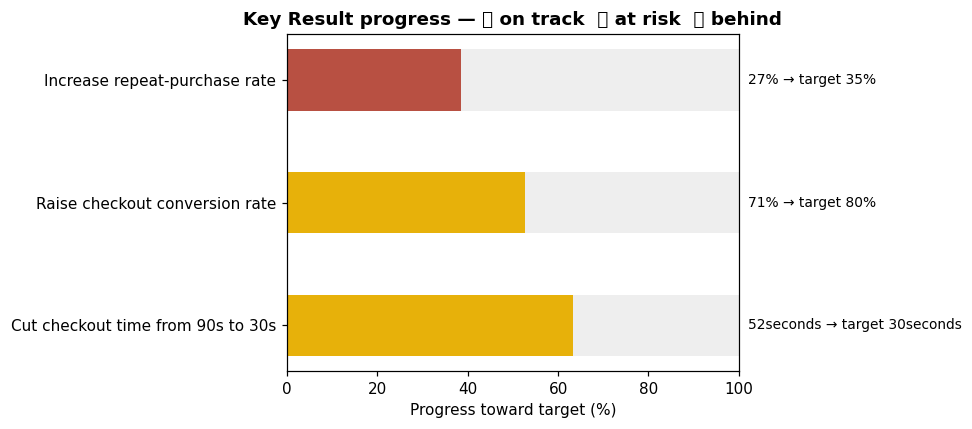

In [6]:
# block3: Plot these KRs on time axis

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(okrs))
colors = ["#2C5F2D" if p >= 70 else "#E7B10A" if p >= 40 else "#B85042" for p in okrs.progress_pct]

ax.barh(y_pos, okrs.progress_pct, color=colors, height=0.5)
ax.barh(y_pos, 100, color="#EEEEEE", height=0.5, zorder=0)
ax.barh(y_pos, okrs.progress_pct, color=colors, height=0.5, zorder=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(okrs.key_result)
ax.set_xlim(0, 100)
ax.set_xlabel("Progress toward target (%)")
ax.set_title("Key Result progress — 🟢 on track  🟡 at risk  🔴 behind", fontsize=12, fontweight="bold")
for i, (p, cur, tgt, unit) in enumerate(zip(okrs.progress_pct, okrs.current, okrs.target, okrs.unit)):
    ax.text(102, i, f"{cur}{unit} → target {tgt}{unit}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
### Mapping KRs to initiatives (outcomes)

roadmap = pd.DataFrame([
    {"initiative": "One-click checkout",        "key_result": "Cut checkout time from 90s to 30s",
     "start": "2026-07-01", "end": "2026-08-15", "confidence": "High"},
    {"initiative": "Guest checkout (no signup)", "key_result": "Cut checkout time from 90s to 30s",
     "start": "2026-08-01", "end": "2026-09-15", "confidence": "Medium"},
    {"initiative": "Saved-payment autofill",     "key_result": "Raise checkout conversion rate",
     "start": "2026-07-15", "end": "2026-08-30", "confidence": "High"},
    {"initiative": "Trust badges & reviews",     "key_result": "Raise checkout conversion rate",
     "start": "2026-09-01", "end": "2026-09-30", "confidence": "Medium"},
    {"initiative": "Referral program",           "key_result": "Increase repeat-purchase rate",
     "start": "2026-10-01", "end": "2026-11-15", "confidence": "Low"},
    {"initiative": "Post-purchase loyalty tier",  "key_result": "Increase repeat-purchase rate",
     "start": "2026-11-01", "end": "2026-12-15", "confidence": "Medium"},
])
roadmap["start"] = pd.to_datetime(roadmap["start"])
roadmap["end"] = pd.to_datetime(roadmap["end"])
roadmap["duration_days"] = (roadmap["end"] - roadmap["start"]).dt.days
roadmap

,initiative,key_result,start,end,confidence,duration_days
0,One-click checkout,Cut checkout time from 90s to 30s,2026-07-01,2026-08-15,High,45
1,Guest checkout (no signup),Cut checkout time from 90s to 30s,2026-08-01,2026-09-15,Medium,45
2,Saved-payment autofill,Raise checkout conversion rate,2026-07-15,2026-08-30,High,46
3,Trust badges & reviews,Raise checkout conversion rate,2026-09-01,2026-09-30,Medium,29
4,Referral program,Increase repeat-purchase rate,2026-10-01,2026-11-15,Low,45
5,Post-purchase loyalty tier,Increase repeat-purchase rate,2026-11-01,2026-12-15,Medium,44


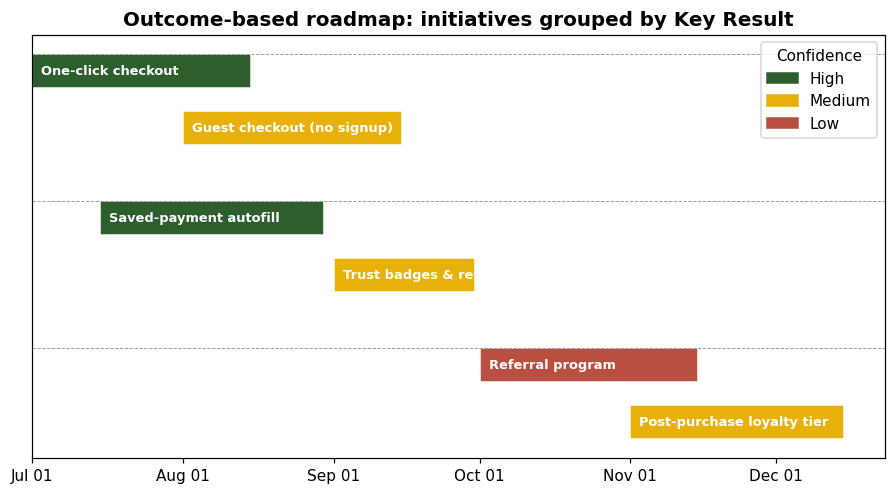

In [9]:
# ## Outcome-based roadmap timeline


conf_color = {"High": "#2C5F2D", "Medium": "#E7B10A", "Low": "#B85042"}
krs = roadmap["key_result"].unique()
fig, ax = plt.subplots(figsize=(10, 5))

y = 0
yticks, yticklabels = [], []
for kr in krs:
    rows = roadmap[roadmap["key_result"] == kr]
    for _, r in rows.iterrows():
        ax.barh(y, r.duration_days, left=r.start, height=0.6,
                color=conf_color[r.confidence], edgecolor="white")
        ax.text(r.start, y, f"  {r.initiative}", va="center", ha="left",
                fontsize=8.5, color="white", fontweight="bold")
        yticks.append(y); yticklabels.append("")
        y += 1
    y += 0.6

ax.set_yticks([]); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Outcome-based roadmap: initiatives grouped by Key Result", fontsize=13, fontweight="bold")
handles = [plt.Rectangle((0,0),1,1, color=c) for c in conf_color.values()]
ax.legend(handles, conf_color.keys(), title="Confidence", loc="upper right")

# annotate KR group boundaries
running = 0
for kr in krs:
    n = len(roadmap[roadmap["key_result"] == kr])
    ax.axhline(running - 0.3, color="#999999", linewidth=0.6, linestyle="--")
    running += n + 0.6

In [14]:
new_okr = pd.DataFrame([
    {
        "objective": "Enhance Data Platform Reliability",
        "key_result": "Improve data pipeline success rate to 99.5%",
        "baseline": 97.8,
        "current": 99.0,
        "target": 99.5,
        "unit": "%",
        "lower_is_better": False,
        "owner": "Data Engineering team",
        "quarter": "Q3"
    }
])

okrs = pd.concat([okrs, new_okr], ignore_index=True)

okrs["progress_pct"] = okrs.apply(progress_pct, axis=1)

new_initiatives = pd.DataFrame([
    {
        "initiative": "Pipeline monitoring enhancement",
        "key_result": "Improve data pipeline success rate to 99.5%",
        "start": "2026-07-20",
        "end": "2026-09-05",
        "confidence": "High"
    },
    {
        "initiative": "Automated failure recovery",
        "key_result": "Improve data pipeline success rate to 99.5%",
        "start": "2026-09-10",
        "end": "2026-10-25",
        "confidence": "Medium"
    }
])

new_initiatives["start"] = pd.to_datetime(new_initiatives["start"])
new_initiatives["end"] = pd.to_datetime(new_initiatives["end"])

new_initiatives["duration_days"] = (
    new_initiatives["end"] - new_initiatives["start"]
).dt.days

roadmap = pd.concat([roadmap, new_initiatives], ignore_index=True)

display(okrs.tail(1))
display(roadmap.tail(2))

,objective,key_result,baseline,current,target,unit,lower_is_better,owner,quarter,progress_pct,Objective,Key Result,Owner
4,Enhance Data Platform Reliability,Improve data pipeline success rate to 99.5%,97.8,99.0,99.5,%,False,Data Engineering team,Q3,70.6,NaN,NaN,NaN


,initiative,key_result,start,end,confidence,duration_days,Key Result,Initiative,Status,Confidence,Start Date,End Date
8,Pipeline monitoring enhancement,Improve data pipeline success rate to 99.5%,2026-07-20,2026-09-05,High,47.0,NaN,NaN,NaN,NaN,NaT,NaT
9,Automated failure recovery,Improve data pipeline success rate to 99.5%,2026-09-10,2026-10-25,Medium,45.0,NaN,NaN,NaN,NaN,NaT,NaT


In [15]:
import ipywidgets as widgets
from IPython.display import clear_output

def display_filtered_roadmap(confidence_value):
    clear_output(wait=True)
    display(confidence_dropdown)

    filtered_data = (
        roadmap
        if confidence_value == 'All'
        else roadmap[roadmap['confidence'] == confidence_value]
    )

    if filtered_data.empty:
        print(f"No initiatives found for confidence level: {confidence_value}")
        return

    confidence_colors = {
        "High": "#2C5F2D",
        "Medium": "#E7B10A",
        "Low": "#B85042"
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    key_results = filtered_data["key_result"].unique()
    y_position = 0

    for kr in key_results:
        rows = filtered_data[filtered_data["key_result"] == kr]

        for _, row in rows.iterrows():
            ax.barh(
                y_position,
                row.duration_days,
                left=row.start,
                height=0.6,
                color=confidence_colors[row.confidence],
                edgecolor="white"
            )

            ax.text(
                row.start,
                y_position,
                f"  {row.initiative}",
                va="center",
                ha="left",
                fontsize=8.5,
                color="white",
                fontweight="bold"
            )

            y_position += 1

        y_position += 0.5
        ax.axhline(
            y_position - 0.25,
            color="#DDDDDD",
            linewidth=0.8,
            linestyle="--"
        )

    ax.invert_yaxis()
    ax.set_yticks([])
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.set_title(
        f"Roadmap Filtered by: {confidence_value} Confidence",
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


confidence_dropdown = widgets.Dropdown(
    options=['All', 'High', 'Medium', 'Low'],
    value='All',
    description='Confidence:'
)

widgets.interactive(
    display_filtered_roadmap,
    confidence_value=confidence_dropdown
)

interactive(children=(Dropdown(description='Confidence:', options=('All', 'High', 'Medium', 'Low'), value='All…

In [5]:
######Adding a New OKR and Supporting Initiatives
import pandas as pd

new_okr = pd.DataFrame([
    {
        "objective": "Build world-class infrastructure",
        "key_result": "Improve system uptime to 99.9%",
        "baseline": 98.5,
        "current": 99.2,
        "target": 99.9,
        "unit": "%",
        "lower_is_better": False,
        "owner": "Platform squad",
        "quarter": "Q3"
    }
])